In [ ]:
pip install --upgrade scikit-learn==1.5.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 17.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import sklearn

print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 1.5.1.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BDA Micro_Project/diabetes.csv')
df.head(6)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0


In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
X = df.drop('Outcome',axis=1)
y=df['Outcome']
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


<Axes: xlabel='count', ylabel='Outcome'>

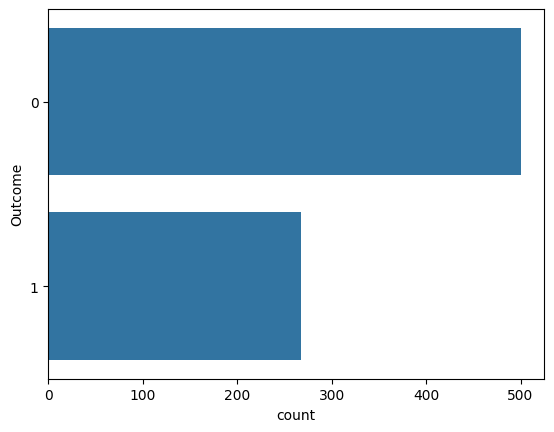

In [ ]:
import seaborn as sns
sns.countplot(data=df,y='Outcome')

In [ ]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [ ]:
# scaler = StandardScaler()

In [ ]:
# scaler.fit(X)

In [ ]:
# st_df = scaler.transform(X)

In [ ]:
# print(st_df)

In [ ]:
# X = st_df
# y = df.Outcome

In [ ]:
print(X)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
X_train , X_test ,y_train ,y_test = train_test_split(X , y, test_size =0.2 ,stratify=y,random_state=2)

In [ ]:
print(X.shape ,X_train.shape,X_test.shape)

(768, 8) (614, 8) (154, 8)


In [ ]:

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [ ]:

best_model = grid_search.best_estimator_


train_accuracy = best_model.score(X_train, y_train)
test_accuracy = best_model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")


Training Accuracy: 0.7866449511400652
Testing Accuracy: 0.7727272727272727


In [ ]:

best_model = grid_search.best_estimator_


train_accuracy = best_model.score(X_train, y_train)
test_accuracy = best_model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")


Training Accuracy: 0.7866449511400652
Testing Accuracy: 0.7727272727272727


In [ ]:

filename = 'diabetes_prediction_pipeline.pkl'
with open(filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Model saved as {filename}")


Model saved as diabetes_prediction_pipeline.pkl


In [ ]:

loaded_model = pickle.load(open('diabetes_prediction_pipeline.pkl', 'rb'))


input_data = (1, 89, 66, 23, 94, 28.1, 0.167, 21)
input_data_array = np.asarray(input_data).reshape(1, -1)


prediction = loaded_model.predict(input_data_array)

if prediction[0] == 0:
    print("The person is not diabetic")
else:
    print("The person is diabetic")


The person is not diabetic


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# model = svm.SVC(kernel='linear')

In [ ]:
# model.fit(X_train,y_train)

SVC(kernel='linear')

In [ ]:
# print(X_test)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
615            3      106             72              0        0  25.8   
80             3      113             44             13        0  22.4   
148            5      147             78              0        0  33.7   
132            3      170             64             37      225  34.5   
501            3       84             72             32        0  37.2   
..           ...      ...            ...            ...      ...   ...   
127            1      118             58             36       94  33.3   
185            7      194             68             28        0  35.9   
85             2      110             74             29      125  32.4   
497            2       81             72             15       76  30.1   
86            13      106             72             54        0  36.6   

     DiabetesPedigreeFunction  Age  
615                     0.207   27  
80                      0.140   22  


In [ ]:
# xtrain_pred = model.predict(X_train)
# print(xtrain_pred)
# train_accuracy = accuracy_score(xtrain_pred,y_train)

[0 0 1 0 1 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0
 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0
 0 0 0 0 1 0 1 0 0 0 1 0 

In [ ]:
# print(train_accuracy)

0.7833876221498371


In [ ]:
# xtest_pred = model.predict(X_test)
# xtest_accuracy = accuracy_score(xtest_pred,y_test)

In [ ]:
# print(xtest_accuracy)

0.7727272727272727


In [ ]:
# input_data = (1,89,66,23,94,28.1,0.167,21)
# in_data_array = np.asarray(input_data)

# input_data_reshaped = in_data_array.reshape(1,-1)

# # std_data = scaler.transform(input_data_reshaped)
# # print(std_data)

# prediction = model.predict(input_data_reshaped)
# print(prediction)


# if(prediction[0] == 0):
#   print("The person is not diabetic")
# else:
#   print("The person is diabetic")

[0]
The person is not diabetic


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Saving the model with extension as .sav and using it for the ui


In [ ]:
import pickle

In [ ]:
filename = 'diabetics_prediction.pkl'
with open('diabetics_prediction.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
loading_model = pickle.load(open('diabetics_prediction.pkl' , 'rb'))

In [ ]:
input_data = (1,89,66,23,94,28.1,0.167,21)

input_data_array = np.asarray(input_data)

input_data_reshape = input_data_array.reshape(1, -1)


prediction = loading_model.predict(input_data_reshape)
print(prediction)


if(prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[0]
The person is not diabetic


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
